In [1]:
# ============================================================
# [0] 🔑 퍼셉트론(Perceptron) - 최초의 인공 신경망
# ============================================================
# 💡 퍼셉트론이란?
# - 1957년에 등장한 가장 간단한 인공 신경망
# - 입력에 가중치를 곱하고 더한 후, 임곗값 넘으면 1 / 아니면 0
# - "선형 분류기"의 한 종류
#
# 📌 동작 방식:
# 1. z = w₁x₁ + w₂x₂ + ... + b (선형 결합)
# 2. y = 1 if z > 0 else 0 (계단 함수)
#
# 💡 한계:
# - XOR 같은 비선형 문제 못 품 (역사적 1차 AI 겨울의 원인)
# - 확률 출력 불가
#
# 📌 이 예제: setosa 품종 분류 (선형 분리 가능 → 잘 작동)
# ============================================================

import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron

iris = load_iris(as_frame=True)
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = (iris.target == 0)

per_clf = Perceptron(random_state=42)
per_clf.fit(X, y)

X_new = [[2, 0.5], [3, 1]]
y_pred = per_clf.predict(X_new)
y_pred

array([ True, False])

In [2]:
# ============================================================
# [1] 🔑 사이킷런의 MLPRegressor - 다층 퍼셉트론
# ============================================================
# 💡 MLP(Multi-Layer Perceptron) = 진짜 신경망의 시작!
# - 여러 층의 뉴런 (Multi-Layer)
# - 비선형 활성화 함수 → 비선형 문제 해결 가능
# - 역전파(backpropagation)로 학습
#
# 📌 hidden_layer_sizes=[50, 50, 50]:
# - 50개 뉴런의 은닉층 3개
# - 각 층 사이는 완전 연결 (fully connected)
#
# ⚠️ 신경망은 특성 스케일에 매우 민감
#    → StandardScaler 필수!
#
# 💡 사이킷런 MLP는 간단한 신경망 실험용
#    실전에서는 TensorFlow/Keras 사용 (다음 셀부터!)
# ============================================================

from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error

housing = fetch_california_housing()
X_train_full, X_test, y_train_full, y_test = train_test_split(
    housing.data, housing.target, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, random_state=42)

mlp_reg = MLPRegressor(hidden_layer_sizes=[50, 50, 50], random_state=42)
pipeline = make_pipeline(StandardScaler(), mlp_reg)
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_valid)
rmse = root_mean_squared_error(y_valid, y_pred)

In [3]:
# ============================================================
# [2] 🔑 Fashion-MNIST 데이터셋 - 본격 딥러닝 시작!
# ============================================================
# 💡 Fashion-MNIST란?
# - MNIST(숫자) 대신 의류 이미지 10종류 분류
# - 28x28 흑백 이미지, 60000장 훈련 + 10000장 테스트
# - 일반 MNIST보다 어려운 문제 (실전급)
#
# 📌 데이터 분할:
# - 전체 60000개 훈련 → 55000개 훈련 + 5000개 검증
# - 검증 세트: 학습 중 과대적합 모니터링
# - 테스트 세트: 최종 평가만!
# ============================================================

import tensorflow as tf

fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
# [3] X_train.shape - (55000, 28, 28)
#     55000개 샘플, 각각 28x28 이미지

X_train.shape

(55000, 28, 28)

In [5]:
# [4] X_train.dtype - uint8 (0~255 정수)
#     이미지 픽셀값은 0(검정)~255(흰색)

X_train.dtype

dtype('uint8')

In [6]:
# ============================================================
# [5] 🔑 정규화(Normalization) - 신경망 학습의 필수 단계!
# ============================================================
# 💡 왜 /255.를 할까?
# - 픽셀값 0~255 → 0~1 범위로 변환
# - 신경망은 큰 입력값에서 불안정 (그래디언트 폭주/소실)
# - 작은 값으로 입력 → 빠르고 안정적인 학습
#
# ⭐ 이미지 데이터의 기본 전처리!
# ============================================================

X_train, X_valid, X_test = X_train / 255., X_valid / 255., X_test / 255.

In [7]:
# [6] 💡 10개 의류 클래스 이름 정의
#      y_train의 0~9 숫자를 사람이 읽을 수 있는 이름으로 매핑

class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

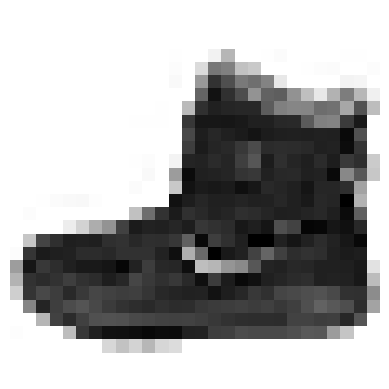

In [8]:
# [7] 💡 첫 번째 이미지 시각화 - cmap="binary"는 흑백

import matplotlib.pyplot as plt

plt.imshow(X_train[0], cmap="binary")
plt.axis('off')
plt.show()

In [9]:
# [8] 첫 번째 이미지의 실제 클래스 이름 확인

class_names[y_train[0]]

'Ankle boot'

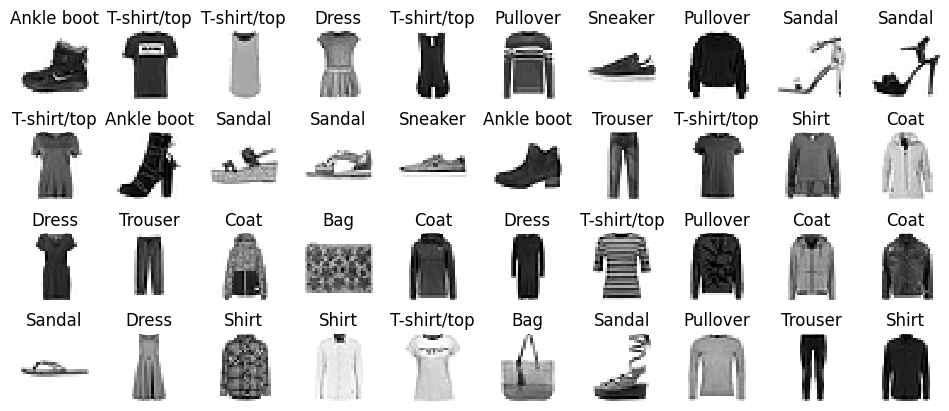

In [10]:
# [9] 💡 40장 이미지를 4x10 격자로 시각화
#      다양한 의류 종류와 각각의 모양을 한눈에 확인

# 그림 10-10
n_rows = 4
n_cols = 10
plt.figure(figsize=(n_cols * 1.2, n_rows * 1.2))

for row in range(n_rows):
  for col in range(n_cols):
    index = n_cols * row + col
    plt.subplot(n_rows, n_cols, index + 1)
    plt.imshow(X_train[index], cmap="binary", interpolation="nearest")
    plt.axis('off')
    plt.title(class_names[y_train[index]])

plt.subplots_adjust(wspace=0.2, hspace=0.5)

plt.show()

In [11]:
# ============================================================
# [10] 🔑 케라스로 신경망 모델 만들기 - 첫 번째 방법
# ============================================================
# 💡 Sequential API: 층을 순서대로 쌓는 가장 간단한 방법
#
# 📌 모델 구조 (Sequential):
# - Input: 28x28 이미지 입력
# - Flatten: 2D 이미지 → 1D 벡터 (784)
# - Dense(300, relu): 첫 번째 은닉층 (300개 뉴런)
# - Dense(100, relu): 두 번째 은닉층 (100개 뉴런)
# - Dense(10, softmax): 출력층 (10개 클래스 확률)
#
# 💡 활성화 함수:
# - ReLU: 은닉층에서 가장 많이 쓰임 (gradient 잘 흐름)
# - Softmax: 다중 분류 출력층 (확률로 변환, 합=1)
#
# tf.random.set_seed(42): 재현성을 위한 시드
# ============================================================

tf.random.set_seed(42)
model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=[28, 28]))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(300, activation="relu"))
model.add(tf.keras.layers.Dense(100, activation="relu"))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

In [12]:
# ============================================================
# [11] 💡 같은 모델, 더 간결한 작성법 (리스트로 한번에)
# ============================================================
# - Sequential 생성자에 층 리스트 한번에 전달
# - input_shape를 Flatten에서 지정 (Input 층 생략 가능)
# - 코드가 짧고 가독성 좋음
# ============================================================

from tensorflow import keras

model = tf.keras.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="relu"),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(10, activation="softmax"),
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
# ============================================================
# [12] 🔑 model.summary() - 모델 구조 한눈에 보기
# ============================================================
# 💡 출력 정보:
# - 각 층의 이름, 출력 shape, 파라미터 수
# - Total params: 전체 학습 가능한 파라미터 수
#
# 📌 파라미터 계산 예:
# - Dense(300): 784×300 + 300 = 235,500 (가중치 + 편향)
# - Dense(100): 300×100 + 100 = 30,100
# - Dense(10): 100×10 + 10 = 1,010
# - 총 ~266,000개 파라미터 학습!
# ============================================================

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# [13] 💡 model.layers - 모델의 모든 층을 리스트로 확인

model.layers

[<Flatten name=flatten_1, built=True>,
 <Dense name=dense_3, built=True>,
 <Dense name=dense_4, built=True>,
 <Dense name=dense_5, built=True>]

In [15]:
# [14] 💡 두 번째 층 (첫 번째 은닉층) 이름 확인
#       기본 이름: "dense", "dense_1" 등 자동 생성

hidden1 = model.layers[1]
hidden1.name

'dense_3'

In [16]:
# [15] 💡 같은 객체임을 확인 (is 연산자)
#       layers[1]을 여러 번 호출해도 같은 인스턴스

hidden1 = model.layers[1]
model.layers[1] is hidden1

True

In [17]:
# ============================================================
# [16] 🔑 학습 전 가중치 확인 - 무작위로 초기화됨
# ============================================================
# 💡 신경망 학습 = 이 가중치들을 최적화하는 것!
# - weights: 입력×뉴런 연결의 강도
# - biases: 각 뉴런의 절편
#
# 💡 초기화 전략:
# - 케라스 기본: Glorot/Xavier 초기화 (대칭 깨기)
# - 모두 0으로 초기화하면 학습 안 됨!
# ============================================================

weights, biases = hidden1.get_weights()
weights

array([[ 0.04686169, -0.06397052,  0.06249513, ...,  0.05464427,
         0.06715576, -0.03487032],
       [ 0.07190274, -0.05639211,  0.01868692, ..., -0.0544553 ,
        -0.06741665, -0.03343727],
       [-0.01940716,  0.00124276,  0.0121958 , ...,  0.03140841,
         0.05467002,  0.05508436],
       ...,
       [ 0.04459967,  0.01423521, -0.01509587, ..., -0.06281497,
         0.03504317, -0.00233545],
       [-0.02585672,  0.07394239, -0.06214305, ..., -0.00244178,
        -0.00933075, -0.0273646 ],
       [-0.00589997,  0.06382173, -0.06631155, ..., -0.03294826,
        -0.02722948,  0.01348913]], dtype=float32)

In [18]:
# [17] weights.shape - (784, 300)
#       784개 입력 → 300개 뉴런 연결

weights.shape

(784, 300)

In [19]:
# [18] 💡 편향(bias)은 0으로 초기화 (기본)

biases

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [20]:
# [19] biases.shape - (300,)
#       각 뉴런마다 하나의 편향

biases.shape

(300,)

In [21]:
# ============================================================
# [20] 🔑 model.compile() - 학습 설정의 핵심!
# ============================================================
# 💡 3가지 핵심 설정:
#
# 1. loss="sparse_categorical_crossentropy":
#    - 다중 분류용 손실 함수
#    - "sparse_": 레이블이 정수일 때 (0~9)
#    - "categorical_": 레이블이 원-핫일 때 ([0,0,1,0,...])
#
# 2. optimizer="sgd":
#    - 확률적 경사 하강법 (기본값)
#    - 더 좋은 옵션: "adam", "rmsprop"
#
# 3. metrics=["accuracy"]:
#    - 학습 중 모니터링할 지표
#    - 손실과 별도로 정확도도 출력됨
# ============================================================

model.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy"])

In [22]:
# ============================================================
# [21] 🔑 model.fit() - 학습 시작! ⭐
# ============================================================
# 💡 신경망 학습의 모든 것이 여기서:
#
# - X_train, y_train: 훈련 데이터와 레이블
# - epochs=30: 전체 데이터를 30번 반복 학습
# - validation_data: 매 에포크마다 검증 점수 측정
#   → 과대적합 모니터링!
#
# 📌 반환값 history:
# - 매 에포크의 손실/정확도 기록
# - history.history 딕셔너리에 저장됨
# - 학습 곡선 그리기에 활용!
#
# 👁️ 출력:
# - Epoch N/30: 진행률
# - loss, accuracy: 훈련 점수
# - val_loss, val_accuracy: 검증 점수
# ============================================================

history = model.fit(X_train, y_train, epochs=30,
                    validation_data=(X_valid, y_valid))

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7626 - loss: 0.7154 - val_accuracy: 0.8276 - val_loss: 0.5099
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8334 - loss: 0.4862 - val_accuracy: 0.8356 - val_loss: 0.4598
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8473 - loss: 0.4418 - val_accuracy: 0.8428 - val_loss: 0.4356
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8549 - loss: 0.4149 - val_accuracy: 0.8458 - val_loss: 0.4198
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8616 - loss: 0.3950 - val_accuracy: 0.8518 - val_loss: 0.4094
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8671 - loss: 0.3791 - val_accuracy: 0.8536 - val_loss: 0.4001
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8720 - loss: 0.3656 - val_accuracy: 0.8582 - val_loss: 0.3908
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8756 - loss: 0.3539 - 

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53356 (\N{HANGUL SYLLABLE KEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


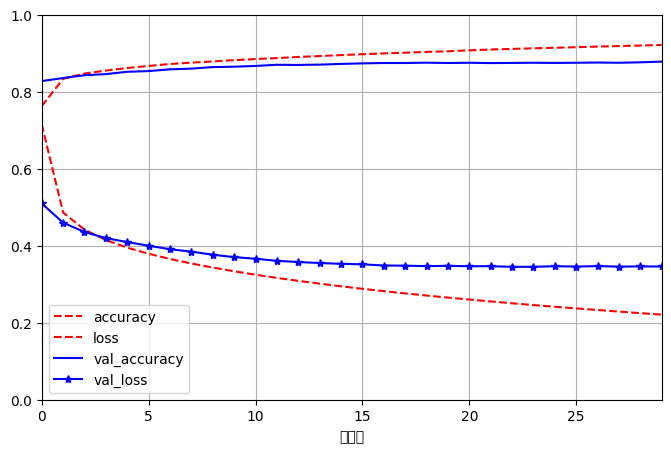

In [23]:
# ============================================================
# [22] 💡 학습 곡선 시각화 - 학습 진행 분석의 핵심!
# ============================================================
# 👁️ 확인 포인트:
# - 훈련 손실(빨강 점선): 계속 감소
# - 검증 손실(파랑 점선): 어느 순간 멈춤/증가 → 과대적합!
# - 두 정확도 곡선이 비슷하게 올라가면 좋은 학습
# - 차이가 크면 과대적합
#
# 💡 pd.DataFrame(history.history): 학습 기록을 데이터프레임으로
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd

pd.DataFrame(history.history).plot(
    figsize=(8, 5), xlim=[0, 29], ylim=[0, 1], grid=True, xlabel="에포크",
    style=["r--", "r--", "b-", "b-*"])
plt.show()

In [24]:
# ============================================================
# [23] 🎯 model.evaluate() - 테스트 세트로 최종 평가
# ============================================================
# - 학습이 완전히 끝난 후에만 사용!
# - 일반화 성능의 진짜 추정치
# - 반환: [test_loss, test_accuracy]
# ============================================================

model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8797 - loss: 0.3600


[0.35999810695648193, 0.8797000050544739]

In [25]:
# ============================================================
# [24] 🔑 model.predict() - 확률 예측
# ============================================================
# 💡 출력층이 softmax라서 확률을 반환
# - shape: (n_samples, n_classes) = (3, 10)
# - 각 행의 합은 1
# - 가장 높은 값이 예측 클래스
#
# 예: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.01, 0.0, 0.99]
#     → 클래스 9 (Ankle boot) 99% 확률
# ============================================================

X_new = X_test[:3]
y_proba = model.predict(X_new)
y_proba.round(2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step


array([[0.  , 0.  , 0.  , 0.  , 0.  , 0.06, 0.  , 0.02, 0.  , 0.92],
       [0.  , 0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ]],
      dtype=float32)

In [26]:
# [25] 💡 가장 확률 높은 클래스 인덱스 추출
#       argmax(axis=-1): 마지막 축에서 최대값 인덱스

import numpy as np
y_pred = y_proba.argmax(axis=-1)
y_pred

array([9, 2, 1])

In [27]:
# [26] 💡 인덱스를 사람이 읽을 수 있는 이름으로 변환
#       np.array(class_names)[y_pred] → 인덱싱으로 한번에

np.array(class_names)[y_pred]

array(['Ankle boot', 'Pullover', 'Trouser'], dtype='<U11')

In [28]:
# [27] 실제 정답과 비교

y_new = y_test[:3]
y_new

array([9, 2, 1], dtype=uint8)

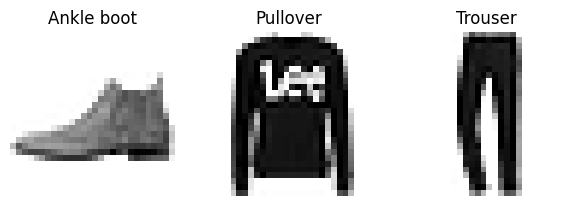

In [29]:
# [28] 💡 예측한 3장 이미지 시각화 - 잘 맞췄는지 눈으로 확인

# 그림 10-12
plt.figure(figsize=(7.2, 2.4))
for index, image in enumerate(X_new):
  plt.subplot(1, 3, index + 1)
  plt.imshow(image, cmap="binary", interpolation="nearest")
  plt.axis('off')
  plt.title(class_names[y_test[index]])
plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()

In [30]:
# ============================================================
# [29] 🔑 회귀 문제: 캘리포니아 주택 가격 예측
# ============================================================
# 💡 분류와 다른 점:
# - 출력층 뉴런 1개 (예측할 값 하나)
# - 활성화 함수 없음 (또는 linear) - 실수값 그대로 출력
# - 손실함수 MSE (mean_squared_error)
#
# 2장에서 본 캘리포니아 주택 데이터를 신경망으로 풀어봄!
# ============================================================

# 캘리포니아 주택 데이터셋 로드
housing = fetch_california_housing()
X_train_full, X_test, y_train_full, y_test = train_test_split(
    housing.data, housing.target, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, random_state=42)

In [31]:
# ============================================================
# [30] 🔑 회귀용 신경망 + Normalization 층 + Adam 옵티마이저
# ============================================================
# 💡 새로운 요소들:
#
# 1. tf.keras.layers.Normalization:
#    - 신경망 안에 정규화 층 직접 포함!
#    - adapt(X_train): 평균/분산 학습
#    - 모델과 함께 저장되어 일관성 보장
#
# 2. 출력층 Dense(1) - 활성화 없음:
#    - 회귀 출력은 임의의 실수값
#    - softmax나 sigmoid 쓰면 안 됨!
#
# 3. Adam 옵티마이저:
#    - SGD보다 진보된 옵티마이저
#    - 학습률을 자동 조절
#    - 보통 SGD보다 빠르고 좋은 성능
#
# 4. loss="mse", metric="RootMeanSquaredError":
#    - 회귀 표준 손실 함수와 평가 지표
# ============================================================

tf.random.set_seed(42)
norm_layer = tf.keras.layers.Normalization(input_shape=X_train.shape[1:])
model = tf.keras.Sequential([
    norm_layer,
    tf.keras.layers.Dense(50, activation="relu"),
    tf.keras.layers.Dense(50, activation="relu"),
    tf.keras.layers.Dense(50, activation="relu"),
    tf.keras.layers.Dense(1),
])
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(loss="mse", optimizer=optimizer, metrics=["RootMeanSquaredError"])
norm_layer.adapt(X_train)
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_valid, y_valid))
mse_test, rmse_test = model.evaluate(X_test, y_test)
X_new = X_test[:3]
y_pred = model.predict(X_new)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


363/363 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - RootMeanSquaredError: 0.8998 - loss: 0.8097 - val_RootMeanSquaredError: 0.6707 - val_loss: 0.4498
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.6156 - loss: 0.3790 - val_RootMeanSquaredError: 0.9702 - val_loss: 0.9413
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - RootMeanSquaredError: 0.5894 - loss: 0.3474 - val_RootMeanSquaredError: 0.6433 - val_loss: 0.4138
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.5845 - loss: 0.3416 - val_RootMeanSquaredError: 1.2728 - val_loss: 1.6199
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.5713 - loss: 0.3264 - val_RootMeanSquaredError: 1.3297 - val_loss: 1.7680
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - RootMeanSquaredError: 0.5743 - loss: 0.3298 - val_RootMeanSquaredError: 1.5307 - val_loss: 2.3429
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - RootMeanSquaredError: 0.5653 - loss: 0.3195 -

In [32]:
# [31] Fashion-MNIST 데이터 다시 로드 (다음 실습용)

# Fasion MNIST 데이터셋 로드
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]

In [33]:
# ============================================================
# [32] 🔑 Keras Tuner 설치 - 하이퍼파라미터 자동 튜닝!
# ============================================================
# 💡 Keras Tuner란?
# - 신경망 하이퍼파라미터 자동 탐색 도구
# - 사이킷런의 GridSearchCV의 신경망 버전
# - 학습률, 층 수, 뉴런 수 등을 자동으로 찾아줌
#
# 📌 clear_session(): 이전 모델의 메모리 정리
# ============================================================

%pip install -q -U keras_tuner

tf.keras.backend.clear_session()
tf.random.set_seed(42)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 4.7 MB/s eta 0:00:00


In [34]:
# ============================================================
# [33] 🔑 build_model() 함수 - 튜닝 대상 정의
# ============================================================
# 💡 hp 객체로 탐색할 하이퍼파라미터 지정:
#
# - hp.Int("n_hidden", 0, 8): 은닉층 개수 (0~8)
# - hp.Int("n_neurons", 16, 256): 뉴런 수 (16~256)
# - hp.Float("learning_rate", 1e-4, 1e-2, sampling="log"):
#   - 학습률: 1e-4~1e-2 (로그 스케일!)
#   - 학습률은 보통 배수로 변하므로 log 샘플링
# - hp.Choice("optimizer", ["sgd", "adam"]): 옵티마이저 선택
#
# 💡 함수가 모델을 반환하면 Keras Tuner가 알아서 시도
# ============================================================

import keras_tuner as kt

def build_model(hp):
  n_hidden = hp.Int("n_hidden", min_value=0, max_value=8, default=2)
  n_neurons = hp.Int("n_neurons", min_value=16, max_value=256)
  learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=1e-2,
                           sampling="log")
  optimizer = hp.Choice("optimizer", values=["sgd", "adam"])
  if optimizer == "sgd":
    optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
  else:
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

  model = tf.keras.Sequential()
  model.add(tf.keras.layers.Flatten())
  for _ in range(n_hidden):
    model.add(tf.keras.layers.Dense(n_neurons, activation="relu"))
  model.add(tf.keras.layers.Dense(10, activation="softmax"))
  model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
                metrics=["accuracy"])
  return model

In [35]:
# ============================================================
# [34] 🔑 RandomSearch - 무작위 탐색으로 최적 조합 찾기
# ============================================================
# 💡 매개변수:
# - objective="val_accuracy": 검증 정확도 최대화
# - max_trials=5: 5가지 조합 시도 (시간 절약)
# - overwrite=True: 이전 결과 덮어쓰기
# - directory, project_name: 결과 저장 위치
#
# 📌 tuner.search(): GridSearchCV의 fit() 같은 역할
# - 각 조합마다 build_model 호출 → 학습 → 검증
# - 가장 좋은 모델 기록
# ============================================================

random_search_tuner = kt.RandomSearch(
    build_model, objective="val_accuracy", max_trials=5, overwrite=True,
    directory="my_fashion_mnist", project_name="my_rnd_search", seed=42)
random_search_tuner.search(X_train, y_train, epochs=10,
                           validation_data=(X_valid, y_valid))

Trial 5 Complete [00h 00m 59s]
val_accuracy: 0.8331999778747559

Best val_accuracy So Far: 0.8575999736785889
Total elapsed time: 00h 05m 10s


In [36]:
# [35] 💡 상위 3개 모델 추출
#       best_model: 가장 좋은 모델

top3_models = random_search_tuner.get_best_models(num_models=3)
best_model = top3_models[0]

In [37]:
# [36] 💡 상위 3개의 하이퍼파라미터 확인
#       어떤 조합이 좋았는지 확인 가능

top3_params = random_search_tuner.get_best_hyperparameters(num_trials=3)
top3_params[0].values

{'n_hidden': 7,
 'n_neurons': 100,
 'learning_rate': 0.0012482904754698163,
 'optimizer': 'sgd'}

In [38]:
# [37] 💡 가장 좋은 trial의 상세 정보 출력
#       하이퍼파라미터 + 점수 한번에 확인

best_trial = random_search_tuner.oracle.get_best_trials(num_trials=1)[0]
best_trial.summary()

Trial 1 summary
Hyperparameters:
n_hidden: 7
n_neurons: 100
learning_rate: 0.0012482904754698163
optimizer: sgd
Score: 0.8575999736785889


In [39]:
# [38] 💡 최고 trial의 마지막 검증 정확도

best_trial.metrics.get_last_value("val_accuracy")

np.float64(0.8575999736785889)

In [40]:
# ============================================================
# [39] 🎯 최종 학습 - 전체 데이터로 다시 학습 후 평가
# ============================================================
# 💡 마지막 단계:
# 1. best_model을 X_train_full (60000개 전부)로 재학습
# 2. 테스트 세트로 최종 평가
#
# 💡 왜 다시 학습?
# - 튜닝 중에는 55000개로 학습했지만
# - 최종 모델은 검증 세트도 활용해 60000개로 학습
# ============================================================

best_model.fit(X_train_full, y_train_full, epochs=10)
test_loss, test_accuracy = best_model.evaluate(X_test, y_test)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.8762 - loss: 0.3361
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.8816 - loss: 0.3233
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8849 - loss: 0.3137
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8881 - loss: 0.3040
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8909 - loss: 0.2962
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8946 - loss: 0.2889
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8956 - loss: 0.2817
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8984 - loss: 0.2757
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9010 - loss: 0.2699
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9032 - loss: 0.2641
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8512 - loss: 0.4281


연습문제

In [41]:
# ============================================================
# [41] 🎓 연습문제: MNIST 손글씨 분류
# ============================================================
# 💡 일반 MNIST로 같은 작업 반복 (Fashion-MNIST보다 쉬움)
# - 0~9 손글씨 숫자 분류
# - 보통 99% 정도 정확도 달성 가능
#
# 📌 전처리:
# - /255.0: 정규화
# - 마지막 5000개를 검증 세트로
# ============================================================

# 데이터 로드
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.mnist.load_data()

# 전처리: 정규화 + 검증셋 분리
X_train, y_train = X_train_full[:-5000] / 255.0, y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:] / 255.0, y_train_full[-5000:]
X_test = X_test / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [42]:
# ============================================================
# [42] 💡 같은 build_model 함수 정의 (MNIST용)
# ============================================================
# 셀 [33]과 거의 동일
# input_shape=[28, 28] 명시
# MNIST는 Fashion-MNIST와 같은 28x28 형태!
# ============================================================

def build_model(hp):
  n_hidden = hp.Int("n_hidden", min_value=0, max_value=8, default=2)
  n_neurons = hp.Int("n_neurons", min_value=16, max_value=256)
  learning_rate = hp.Float(
      "learning_rate",
      min_value=1e-4,
      max_value=1e-2,
      sampling="log"
  )
  optimizer_name = hp.Choice("optimizer", values=["sgd", "adam"])

  if optimizer_name == "sgd":
    optimizer = keras.optimizers.SGD(learning_rate=learning_rate)
  else:
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

  model = keras.Sequential()
  model.add(keras.layers.Flatten(input_shape=[28, 28]))
  for _ in range(n_hidden):
    model.add(keras.layers.Dense(n_neurons, activation="relu"))

  model.add(keras.layers.Dense(10, activation="softmax"))

  model.compile(
    loss="sparse_categorical_crossentropy",
               optimizer=optimizer,
               metrics=["accuracy"]
  )

  return model

In [43]:
# ============================================================
# [43] 💡 더 많은 시도 (max_trials=10)
# ============================================================
# 10가지 조합으로 더 정밀한 탐색
# 정확한 결과를 원하면 max_trials 늘리기 (대신 시간 ↑)
# ============================================================

tuner = kt.RandomSearch(
  build_model,
  objective="val_accuracy",
  max_trials=10,
  overwrite=True,
  directory="mnist_tuner",
  project_name="mnist_mlp"
)

tuner.search(
  X_train, y_train,
  epochs=10,
  validation_data=(X_valid, y_valid)
)

Trial 10 Complete [00h 00m 51s]
val_accuracy: 0.8564000129699707

Best val_accuracy So Far: 0.979200005531311
Total elapsed time: 00h 09m 47s


In [44]:
# [44] 💡 최적 모델과 하이퍼파라미터 추출 및 출력

top3_models = tuner.get_best_models(num_models=3)
best_model = top3_models[0]

top3_params = tuner.get_best_hyperparameters(num_trials=3)
print(top3_params[0].values) # 최상의 하이퍼파라미터 값

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


{'n_hidden': 6, 'n_neurons': 118, 'learning_rate': 0.0012940465465259134, 'optimizer': 'adam'}


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [45]:
# [45] 최고 trial 상세 정보

best_trial = tuner.oracle.get_best_trials(num_trials=1)[0]
best_trial.summary()

Trial 05 summary
Hyperparameters:
n_hidden: 6
n_neurons: 118
learning_rate: 0.0012940465465259134
optimizer: adam
Score: 0.979200005531311


In [46]:
# [46] 최고 검증 정확도 출력

print(best_trial.metrics.get_last_value("val_accuracy"))

0.979200005531311


In [47]:
# ============================================================
# [47] 🎯 최종 학습 및 평가
# ============================================================
# - 전체 데이터(X_train_full)로 30 에포크 재학습
# - 테스트 세트로 최종 정확도 확인
# - MNIST에서는 보통 97% 이상 나옴!
#
# 💡 정리: 이게 신경망 워크플로우의 전형
# 1. 데이터 전처리 (정규화)
# 2. 모델 구조 설계
# 3. 하이퍼파라미터 튜닝
# 4. 전체 데이터로 재학습
# 5. 테스트 세트로 최종 평가
# ============================================================

X_train_full_scaled = X_train_full / 255.0 # 최종 학습용
best_model.fit(X_train_full_scaled, y_train_full,
epochs=30)
test_loss, test_accuracy = best_model.evaluate(X_test,
y_test)
print(f"\n테스트 정확도: {test_accuracy*100:.2f}%")

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9870 - loss: 0.0520
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9901 - loss: 0.0361
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9904 - loss: 0.0343
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9905 - loss: 0.0352
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9920 - loss: 0.0285
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9918 - loss: 0.0309
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9916 - loss: 0.0291
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9929 - loss: 0.0272
Epoch 9/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9931 - loss: 0.0243
Epoch 10/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9933 - loss: 0.0250
Epoch 11/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9939 - loss: 0.0249
Epoch 12/30
1875/1875 ━━━━━━━━